In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent chart appearance
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_PATH = Path("healthcare_performance.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

INDICATORS = [
    "anc_coverage",
    "institutional_delivery",
    "immunization",
    "high_risk_cases",
]

PERCENTAGE_INDICATORS = [
    "anc_coverage",
    "institutional_delivery",
    "immunization",
]

REQUIRED_COLUMNS = ["month", "district", *INDICATORS]

# Human-defined defaults. In Streamlit, connect these to UI sliders.
TREND_THRESHOLD_PCT = 10.0
CORRELATION_THRESHOLD = 0.70
IQR_MULTIPLIER = 1.5


## 1. Load the data

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Place the CSV beside this notebook or update DATA_PATH."
    )

raw_df = pd.read_csv(DATA_PATH)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")
print("\nColumn names:")
print(raw_df.columns.tolist())

display(raw_df.head(10))


Rows: 144
Columns: 6

Column names:
['month', 'district', 'anc_coverage', 'institutional_delivery', 'immunization', 'high_risk_cases']


,month,district,anc_coverage,institutional_delivery,immunization,high_risk_cases
0,2026-01-01,Ahmedabad,83,89,93,12
1,2026-01-01,Anand,82,88,91,12
2,2026-01-01,Bharuch,79,85,90,15
3,2026-01-01,Bhavnagar,76,82,86,19
4,2026-01-01,Gandhinagar,85,91,92,7
5,2026-01-01,Jamnagar,78,82,89,15
6,2026-01-01,Junagadh,80,86,89,15
7,2026-01-01,Kheda,78,85,90,16
8,2026-01-01,Mehsana,82,87,93,11
9,2026-01-01,Rajkot,77,84,88,18


## 2. data preprocessing


In [ ]:
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(raw_df.columns))

if missing_columns:
    raise ValueError(f"Required columns missing from CSV: {missing_columns}")

print("Data types and non-null counts:")
raw_df.info()

quality_summary = pd.DataFrame({
    "data_type": raw_df.dtypes.astype(str),
    "missing_count": raw_df.isna().sum(),
    "missing_percent": (raw_df.isna().mean() * 100).round(2),
    "unique_values": raw_df.nunique(dropna=True),
})

display(quality_summary)

print("Exact duplicate rows:", int(raw_df.duplicated().sum()))


Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   month                   144 non-null    object
 1   district                144 non-null    object
 2   anc_coverage            144 non-null    int64 
 3   institutional_delivery  144 non-null    int64 
 4   immunization            144 non-null    int64 
 5   high_risk_cases         144 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 6.9+ KB


,data_type,missing_count,missing_percent,unique_values
month,object,0,0.0,12
district,object,0,0.0,12
anc_coverage,int64,0,0.0,21
institutional_delivery,int64,0,0.0,15
immunization,int64,0,0.0,14
high_risk_cases,int64,0,0.0,16


Exact duplicate rows: 0


## 3. Preprocess and validate the data

In [ ]:
df = raw_df.copy()

# Normalize dates and district labels.
df["month"] = pd.to_datetime(df["month"], errors="coerce")
df["district"] = df["district"].astype("string").str.strip()

# Convert indicators to numeric. Invalid values become NaN and are reported.
for column in INDICATORS:
    df[column] = pd.to_numeric(df[column], errors="coerce")

invalid_required_mask = (
    df["month"].isna()
    | df["district"].isna()
    | df["district"].eq("")
    | df[INDICATORS].isna().any(axis=1)
)

duplicate_key_mask = df.duplicated(
    subset=["district", "month"],
    keep="first"
)

preprocessing_summary = pd.DataFrame({
    "check": [
        "Input rows",
        "Rows with invalid required fields",
        "Duplicate district-month rows",
    ],
    "count": [
        len(df),
        int(invalid_required_mask.sum()),
        int(duplicate_key_mask.sum()),
    ],
})

display(preprocessing_summary)

# Keep only rows that can be analyzed unambiguously.
df = df.loc[~invalid_required_mask & ~duplicate_key_mask].copy()
df = df.sort_values(["district", "month"]).reset_index(drop=True)

print(f"Rows retained for analysis: {len(df):,}")
print(f"Districts: {df['district'].nunique()}")
print(f"Distinct months: {df['month'].nunique()}")
display(df.head())


,check,count
0,Input rows,144
1,Rows with invalid required fields,0
2,Duplicate district-month rows,0


Rows retained for analysis: 144
Districts: 12
Distinct months: 12


,month,district,anc_coverage,institutional_delivery,immunization,high_risk_cases
0,2026-01-01,Ahmedabad,83,89,93,12
1,2026-02-01,Ahmedabad,82,89,92,10
2,2026-03-01,Ahmedabad,85,90,93,12
3,2026-04-01,Ahmedabad,86,92,93,9
4,2026-05-01,Ahmedabad,87,90,94,10


In [ ]:
# Check percentage ranges. These rows are flagged for review, not automatically modified.
range_issues = []

for column in PERCENTAGE_INDICATORS:
    outside_range = ~df[column].between(0, 100)

    if outside_range.any():
        issue_rows = df.loc[
            outside_range, ["month", "district", column]
        ].rename(columns={column: "value"})

        issue_rows["indicator"] = column
        range_issues.append(issue_rows)

range_issues_df = (
    pd.concat(range_issues, ignore_index=True)
    if range_issues
    else pd.DataFrame(columns=["month", "district", "value", "indicator"])
)

print("Percentage values outside 0 to 100:", len(range_issues_df))
display(range_issues_df.head(20))


Percentage values outside 0 to 100: 0


,month,district,value,indicator


## 4. visualizing preprocessing

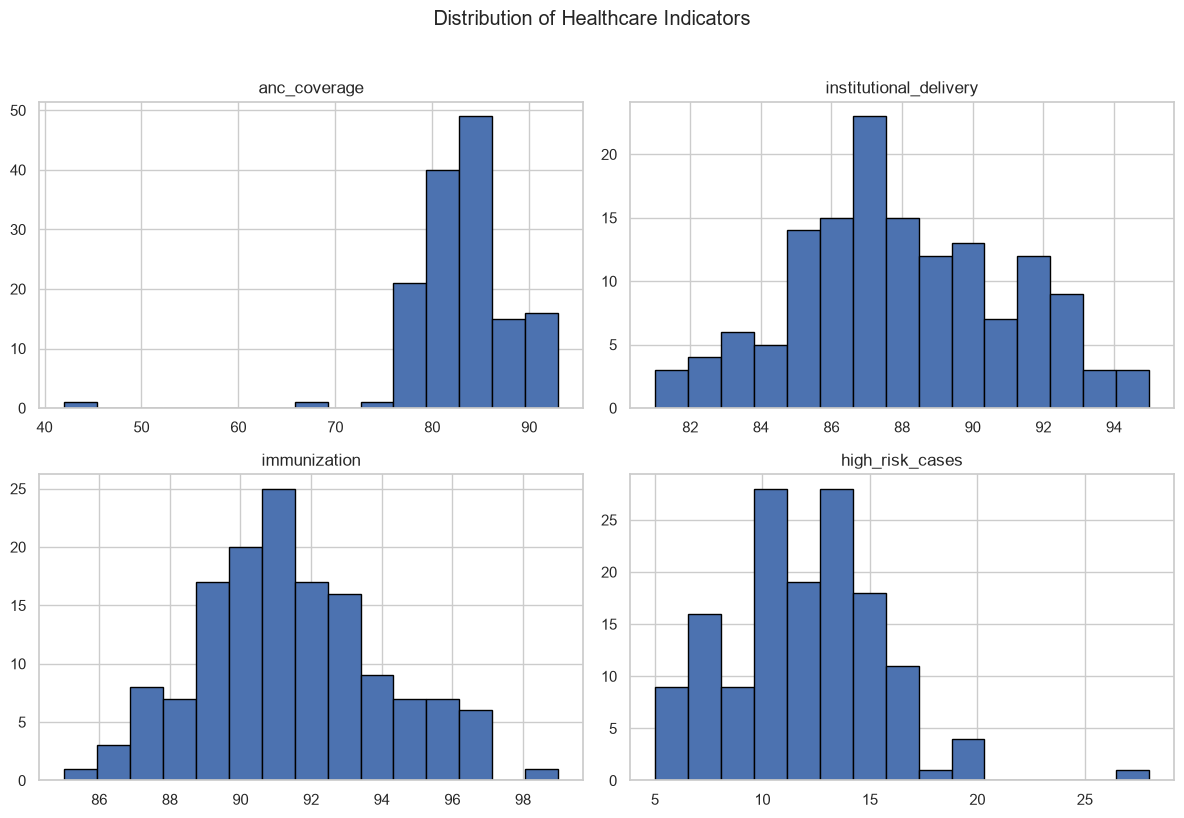

In [7]:
# Distribution of each indicator
df[INDICATORS].hist(figsize=(12, 8), bins=15, edgecolor="black")
plt.suptitle("Distribution of Healthcare Indicators", y=1.02)
plt.tight_layout()
plt.show()


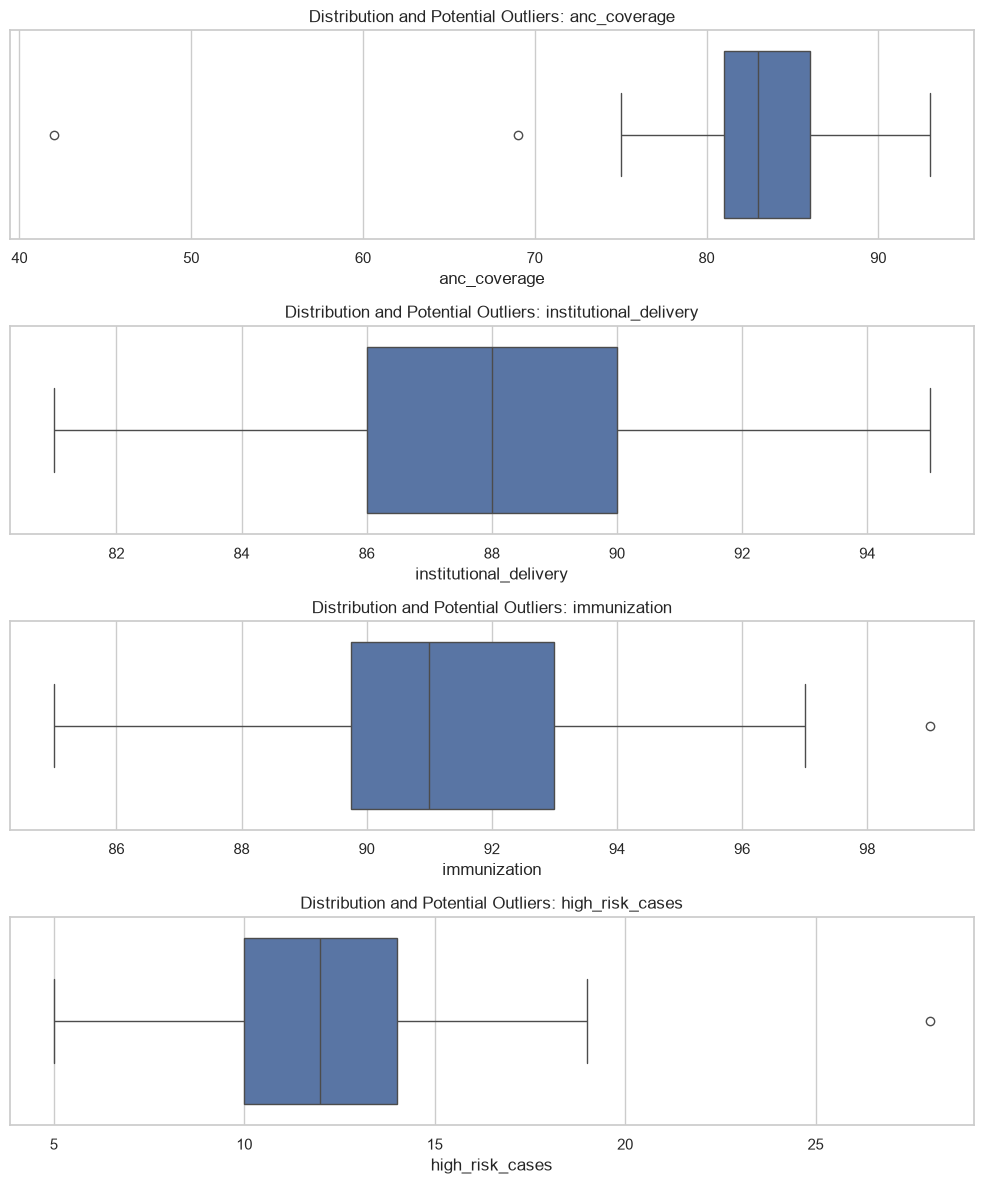

In [8]:
# Boxplots help visually inspect unusually high or low observations.
fig, axes = plt.subplots(
    nrows=len(INDICATORS),
    ncols=1,
    figsize=(10, 3 * len(INDICATORS))
)

for ax, column in zip(axes, INDICATORS):
    sns.boxplot(data=df, x=column, ax=ax)
    ax.set_title(f"Distribution and Potential Outliers: {column}")

plt.tight_layout()
plt.show()


## 5. Trend detection

For each district and indicator, compare a month with the previous available observation for that district.

In [9]:
def detect_trends(
    data: pd.DataFrame,
    indicators: list[str],
    threshold_pct: float = 10.0,
) -> pd.DataFrame:
    """Return district-indicator-month changes exceeding a percentage threshold."""
    results = []
    ordered = data.sort_values(["district", "month"])

    for indicator in indicators:
        previous_values = ordered.groupby("district")[indicator].shift(1)

        current_values = ordered[indicator]
        valid_previous = previous_values.notna() & previous_values.ne(0)

        change_pct = (
            (current_values - previous_values)
            / previous_values.where(valid_previous)
            * 100
        )

        flagged_rows = ordered.loc[
            change_pct.abs().ge(threshold_pct) & change_pct.notna()
        ].copy()

        flagged_rows["prev_value"] = previous_values.loc[flagged_rows.index]
        flagged_rows["change_pct"] = change_pct.loc[flagged_rows.index]

        for _, row in flagged_rows.iterrows():
            results.append({
                "type": "trend",
                "indicator": indicator,
                "entity": row["district"],
                "period": row["month"].strftime("%Y-%m"),
                "value": float(row[indicator]),
                "prev_value": float(row["prev_value"]),
                "change_pct": float(row["change_pct"]),
                "metric": "percentage_change",
            })

    return pd.DataFrame(results)


trends_df = detect_trends(df, INDICATORS, TREND_THRESHOLD_PCT)

print(f"Significant trends found: {len(trends_df)}")
display(trends_df.head(20))


Significant trends found: 76


,type,indicator,entity,period,value,prev_value,change_pct,metric
0,trend,anc_coverage,Ahmedabad,2026-08,69.0,85.0,-18.823529,percentage_change
1,trend,anc_coverage,Ahmedabad,2026-09,85.0,69.0,23.188406,percentage_change
2,trend,anc_coverage,Mehsana,2026-08,42.0,84.0,-50.000000,percentage_change
3,trend,anc_coverage,Mehsana,2026-09,86.0,42.0,104.761905,percentage_change
4,trend,high_risk_cases,Ahmedabad,2026-02,10.0,12.0,-16.666667,percentage_change
5,trend,high_risk_cases,Ahmedabad,2026-03,12.0,10.0,20.000000,percentage_change
6,trend,high_risk_cases,Ahmedabad,2026-04,9.0,12.0,-25.000000,percentage_change
7,trend,high_risk_cases,Ahmedabad,2026-05,10.0,9.0,11.111111,percentage_change
8,trend,high_risk_cases,Ahmedabad,2026-08,13.0,10.0,30.000000,percentage_change
9,trend,high_risk_cases,Ahmedabad,2026-09,10.0,13.0,-23.076923,percentage_change


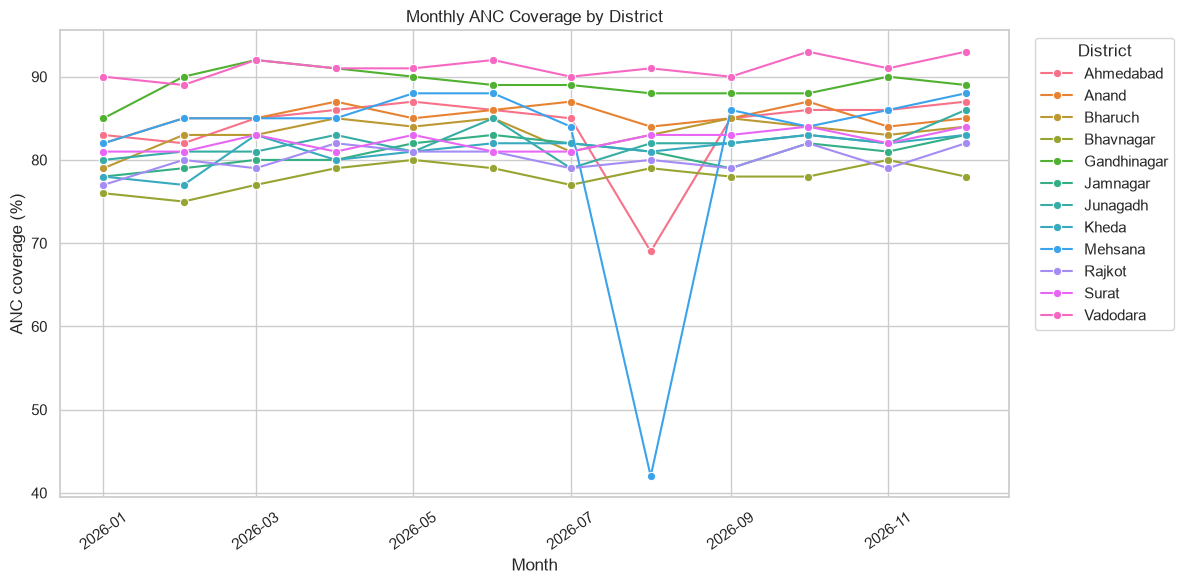

In [10]:
# Visualize ANC coverage over time for each district.
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x="month",
    y="anc_coverage",
    hue="district",
    marker="o"
)
plt.title("Monthly ANC Coverage by District")
plt.xlabel("Month")
plt.ylabel("ANC coverage (%)")
plt.xticks(rotation=35)
plt.legend(title="District", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6. Outlier detection with the IQR rule

In [11]:
def detect_iqr_outliers(
    data: pd.DataFrame,
    indicators: list[str],
    multiplier: float = 1.5,
) -> pd.DataFrame:
    """Identify values outside the IQR bounds for each indicator."""
    results = []

    for indicator in indicators:
        q1 = data[indicator].quantile(0.25)
        q3 = data[indicator].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - multiplier * iqr
        upper_bound = q3 + multiplier * iqr

        mask = (
            (data[indicator] < lower_bound)
            | (data[indicator] > upper_bound)
        )

        for _, row in data.loc[mask].iterrows():
            results.append({
                "type": "outlier",
                "indicator": indicator,
                "entity": row["district"],
                "period": row["month"].strftime("%Y-%m"),
                "value": float(row[indicator]),
                "prev_value": np.nan,
                "change_pct": np.nan,
                "metric": "iqr_outlier",
                "lower_bound": float(lower_bound),
                "upper_bound": float(upper_bound),
            })

    return pd.DataFrame(results)


outliers_df = detect_iqr_outliers(df, INDICATORS, IQR_MULTIPLIER)

print(f"Potential outliers found: {len(outliers_df)}")
display(outliers_df.head(20))


Potential outliers found: 4


,type,indicator,entity,period,value,prev_value,change_pct,metric,lower_bound,upper_bound
0,outlier,anc_coverage,Ahmedabad,2026-08,69.0,NaN,NaN,iqr_outlier,73.500,93.500
1,outlier,anc_coverage,Mehsana,2026-08,42.0,NaN,NaN,iqr_outlier,73.500,93.500
2,outlier,immunization,Vadodara,2026-12,99.0,NaN,NaN,iqr_outlier,84.875,97.875
3,outlier,high_risk_cases,Mehsana,2026-08,28.0,NaN,NaN,iqr_outlier,4.000,20.000


## 7. Correlation analysis


In [12]:
def detect_correlations(
    data: pd.DataFrame,
    indicators: list[str],
    threshold: float = 0.70,
):
    """Return the correlation matrix and unique indicator pairs above threshold."""
    matrix = data[indicators].corr(method="pearson")
    flagged_pairs = []

    for i, indicator_a in enumerate(indicators):
        for indicator_b in indicators[i + 1:]:
            correlation = matrix.loc[indicator_a, indicator_b]

            if pd.notna(correlation) and abs(correlation) >= threshold:
                flagged_pairs.append({
                    "type": "correlation",
                    "indicator": indicator_a,
                    "related_indicator": indicator_b,
                    "entity": "All districts",
                    "period": "Full dataset",
                    "value": float(correlation),
                    "metric": "pearson_r",
                })

    return matrix, pd.DataFrame(flagged_pairs)


correlation_matrix, correlations_df = detect_correlations(
    df,
    INDICATORS,
    CORRELATION_THRESHOLD,
)

display(correlation_matrix.round(3))
print(f"Correlation pairs flagged: {len(correlations_df)}")
display(correlations_df)


,anc_coverage,institutional_delivery,immunization,high_risk_cases
anc_coverage,1.000,0.621,0.629,-0.822
institutional_delivery,0.621,1.000,0.903,-0.801
immunization,0.629,0.903,1.000,-0.768
high_risk_cases,-0.822,-0.801,-0.768,1.000


Correlation pairs flagged: 4


,type,indicator,related_indicator,entity,period,value,metric
0,correlation,anc_coverage,high_risk_cases,All districts,Full dataset,-0.821593,pearson_r
1,correlation,institutional_delivery,immunization,All districts,Full dataset,0.903468,pearson_r
2,correlation,institutional_delivery,high_risk_cases,All districts,Full dataset,-0.801017,pearson_r
3,correlation,immunization,high_risk_cases,All districts,Full dataset,-0.767968,pearson_r


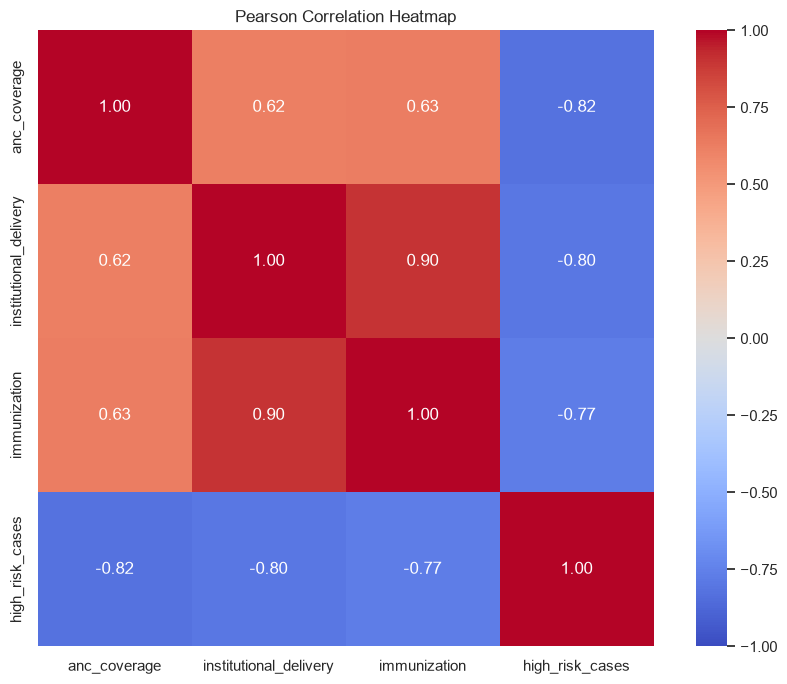

In [13]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()


## 8. Generate structured insights

This section separates computed evidence from human-defined interpretation.

**Human decisions:** the trend threshold, IQR multiplier, correlation threshold, and severity policy are chosen explicitly. They are not learned from the data and are not clinical standards.

**Automated work:** calculations, filtering, severity assignment under the chosen policy, IDs, and explanation templates are generated from actual records.

For trends, the example severity policy marks a change as High at 1.5 times the configured threshold and Medium when it crosses the threshold but remains below that level. Outliers and correlations are assigned Medium by default for review, rather than pretending that a statistical rule establishes clinical severity.


In [14]:
def trend_severity(change_pct: float, threshold_pct: float) -> str:
    """Example review-priority policy, not a clinical risk classification."""
    if abs(change_pct) >= 1.5 * threshold_pct:
        return "High"
    return "Medium"


def generate_insights(
    trends: pd.DataFrame,
    outliers: pd.DataFrame,
    correlations: pd.DataFrame,
    trend_threshold_pct: float,
) -> pd.DataFrame:
    """Convert analytical findings into a consistent, exportable insight schema."""
    insights = []

    for row in trends.to_dict("records"):
        direction = "increased" if row["change_pct"] > 0 else "decreased"

        insights.append({
            "type": "trend",
            "indicator": row["indicator"],
            "entity": row["entity"],
            "period": row["period"],
            "metric": row["value"],
            "change": row["change_pct"],
            "value": row["value"],
            "prev_value": row["prev_value"],
            "change_pct": row["change_pct"],
            "severity": trend_severity(
                row["change_pct"], trend_threshold_pct
            ),
            "explanation": (
                f"{row['indicator']} in {row['entity']} {direction} by "
                f"{abs(row['change_pct']):.1f}% in {row['period']} compared "
                f"with the previous available month. This exceeds the "
                f"{trend_threshold_pct:.1f}% configured threshold."
            ),
        })

    for row in outliers.to_dict("records"):
        insights.append({
            "type": "outlier",
            "indicator": row["indicator"],
            "entity": row["entity"],
            "period": row["period"],
            "metric": row["value"],
            "change": np.nan,
            "value": row["value"],
            "prev_value": np.nan,
            "change_pct": np.nan,
            "severity": "Medium",
            "explanation": (
                f"{row['indicator']} in {row['entity']} during {row['period']} "
                "falls outside the IQR bounds calculated from the dataset and "
                "should be reviewed."
            ),
        })

    for row in correlations.to_dict("records"):
        correlation = row["value"]

        insights.append({
            "type": "correlation",
            "indicator": (
                f"{row['indicator']}:{row['related_indicator']}"
            ),
            "entity": row["entity"],
            "period": row["period"],
            "metric": correlation,
            "change": np.nan,
            "value": correlation,
            "prev_value": np.nan,
            "change_pct": np.nan,
            "severity": "Medium",
            "explanation": (
                f"{row['indicator']} and {row['related_indicator']} have "
                f"a Pearson correlation of {correlation:.2f}. This is an "
                "exploratory association and does not establish causation."
            ),
        })

    columns = [
        "insight_id", "type", "indicator", "entity", "period",
        "metric", "change", "value", "prev_value", "change_pct",
        "severity", "explanation",
    ]

    insights_df = pd.DataFrame(insights)

    if insights_df.empty:
        return pd.DataFrame(columns=columns)

    insights_df.insert(
        0,
        "insight_id",
        [f"INS-{number:04d}" for number in range(1, len(insights_df) + 1)],
    )

    return insights_df[columns]


insights_df = generate_insights(
    trends_df,
    outliers_df,
    correlations_df,
    TREND_THRESHOLD_PCT,
)

print(f"Total insights generated: {len(insights_df)}")
display(insights_df.head(30))


Total insights generated: 84


,insight_id,type,indicator,entity,period,metric,change,value,prev_value,change_pct,severity,explanation
0,INS-0001,trend,anc_coverage,Ahmedabad,2026-08,69.0,-18.823529,69.0,85.0,-18.823529,High,anc_coverage in Ahmedabad decreased by 18.8% i...
1,INS-0002,trend,anc_coverage,Ahmedabad,2026-09,85.0,23.188406,85.0,69.0,23.188406,High,anc_coverage in Ahmedabad increased by 23.2% i...
2,INS-0003,trend,anc_coverage,Mehsana,2026-08,42.0,-50.000000,42.0,84.0,-50.000000,High,anc_coverage in Mehsana decreased by 50.0% in ...
3,INS-0004,trend,anc_coverage,Mehsana,2026-09,86.0,104.761905,86.0,42.0,104.761905,High,anc_coverage in Mehsana increased by 104.8% in...
4,INS-0005,trend,high_risk_cases,Ahmedabad,2026-02,10.0,-16.666667,10.0,12.0,-16.666667,High,high_risk_cases in Ahmedabad decreased by 16.7...
5,INS-0006,trend,high_risk_cases,Ahmedabad,2026-03,12.0,20.000000,12.0,10.0,20.000000,High,high_risk_cases in Ahmedabad increased by 20.0...
6,INS-0007,trend,high_risk_cases,Ahmedabad,2026-04,9.0,-25.000000,9.0,12.0,-25.000000,High,high_risk_cases in Ahmedabad decreased by 25.0...
7,INS-0008,trend,high_risk_cases,Ahmedabad,2026-05,10.0,11.111111,10.0,9.0,11.111111,Medium,high_risk_cases in Ahmedabad increased by 11.1...
8,INS-0009,trend,high_risk_cases,Ahmedabad,2026-08,13.0,30.000000,13.0,10.0,30.000000,High,high_risk_cases in Ahmedabad increased by 30.0...
9,INS-0010,trend,high_risk_cases,Ahmedabad,2026-09,10.0,-23.076923,10.0,13.0,-23.076923,High,high_risk_cases in Ahmedabad decreased by 23.1...


## 9. Visualize insight severity


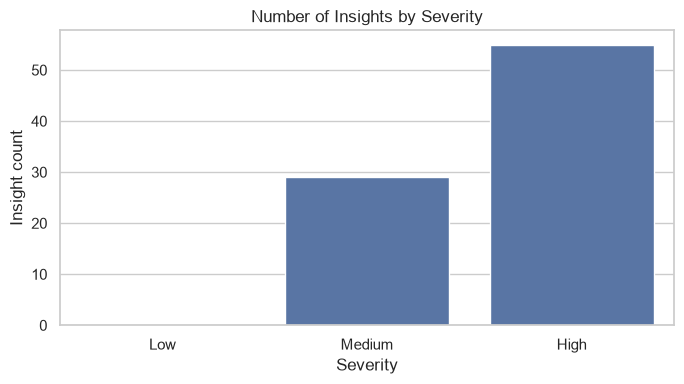

In [15]:
if insights_df.empty:
    print("No insights were flagged using the current thresholds.")
else:
    severity_order = ["Low", "Medium", "High"]
    severity_counts = (
        insights_df["severity"]
        .value_counts()
        .reindex(severity_order, fill_value=0)
        .rename_axis("severity")
        .reset_index(name="count")
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=severity_counts,
        x="severity",
        y="count",
        order=severity_order,
    )
    plt.title("Number of Insights by Severity")
    plt.xlabel("Severity")
    plt.ylabel("Insight count")
    plt.tight_layout()
    plt.show()


## 10. Export required outputs


In [16]:
insights_path = OUTPUT_DIR / "insights.csv"
correlation_path = OUTPUT_DIR / "correlation_matrix.csv"

insights_df.to_csv(insights_path, index=False)
correlation_matrix.to_csv(correlation_path)

print(f"Insights saved to: {insights_path.resolve()}")
print(f"Correlation matrix saved to: {correlation_path.resolve()}")


Insights saved to: D:\Automated-Insight-Generation\outputs\insights.csv
Correlation matrix saved to: D:\Automated-Insight-Generation\outputs\correlation_matrix.csv


## 11. Summary and limitations

- The notebook implements data loading, validation, preprocessing, trend detection, IQR outlier detection, Pearson correlation, structured insight generation, visualization, and CSV export.
- The expanded dataset includes synthetic practice data. It must not be represented as official healthcare data.
- IQR outliers are candidates for investigation, not necessarily errors.
- Pearson correlation does not establish causation and can be unstable with small samples.
- Percentage changes are undefined when the previous value is zero or missing.
- Severity levels reflect an explicit example policy, not clinical standards.
- This notebook covers the analytical core. The Streamlit application should add CSV upload, live filters, threshold sliders, an insight table, and interactive Plotly charts.
